Dataset: https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather?resource=download

The problem:

We want to accurately predict the price of energy in EUR/MWh using past hourly data. This is important as energy markets function similarly to financial markets and energy price prediction helps with transitioning to a renewable based electrical infrastructure.

Sequential models are needed for this problem as unlike regular models the assumption is not that data points or features are independent. This means we can capture the relationship of these points of features as time passes which is extremely important for the energy market as the suppy and demand depends on how much was generated in the past hours.

In [35]:
import kagglehub
path = kagglehub.dataset_download("nicholasjhana/energy-consumption-generation-prices-and-weather")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'energy-consumption-generation-prices-and-weather' dataset.
Path to dataset files: /kaggle/input/energy-consumption-generation-prices-and-weather


Pre-processing and EDA

In [36]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, 'energy_dataset.csv'))
display(df.head())

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [37]:
print("DataFrame Info (Data Types and Null Counts):")
df.info()

DataFrame Info (Data Types and Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal      

In [48]:
print("Summary Statistics:")
display(df.describe())

Summary Statistics:


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage consumption,...,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,price actual
count,35064.000000,35064.000000,35064.0,35064.000000,35064.000000,35064.000000,35064.0,35064.0,35064.0,35064.000000,...,35064.000000,35064.0,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.0,35064.000000,35064.000000
mean,383.513540,448.059208,0.0,5622.737488,4256.065742,298.319789,0.0,0.0,0.0,475.577343,...,2605.114735,0.0,6263.907039,60.228585,85.639702,1432.665925,269.452133,0.0,5464.479769,57.884023
std,85.330814,354.477568,0.0,2201.265238,1961.097443,52.506441,0.0,0.0,0.0,792.191889,...,1834.728624,0.0,839.464380,20.233185,14.073940,1679.688577,50.181934,0.0,3212.866588,14.204083
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,9.330000
25%,333.000000,0.000000,0.0,4127.000000,2528.750000,263.000000,0.0,0.0,0.0,0.000000,...,1078.000000,0.0,5761.000000,53.000000,74.000000,71.000000,240.000000,0.0,2933.750000,49.347500
50%,367.000000,509.000000,0.0,4971.000000,4473.000000,300.000000,0.0,0.0,0.0,68.000000,...,2165.000000,0.0,6563.500000,57.000000,88.000000,616.000000,279.000000,0.0,4850.500000,58.020000
75%,433.000000,757.000000,0.0,6428.000000,5837.000000,330.000000,0.0,0.0,0.0,615.000000,...,3756.250000,0.0,7024.000000,80.000000,97.000000,2575.250000,310.000000,0.0,7397.000000,68.010000
max,592.000000,999.000000,0.0,20034.000000,8359.000000,449.000000,0.0,0.0,0.0,4523.000000,...,9728.000000,0.0,7117.000000,106.000000,119.000000,5792.000000,357.000000,0.0,17436.000000,116.800000


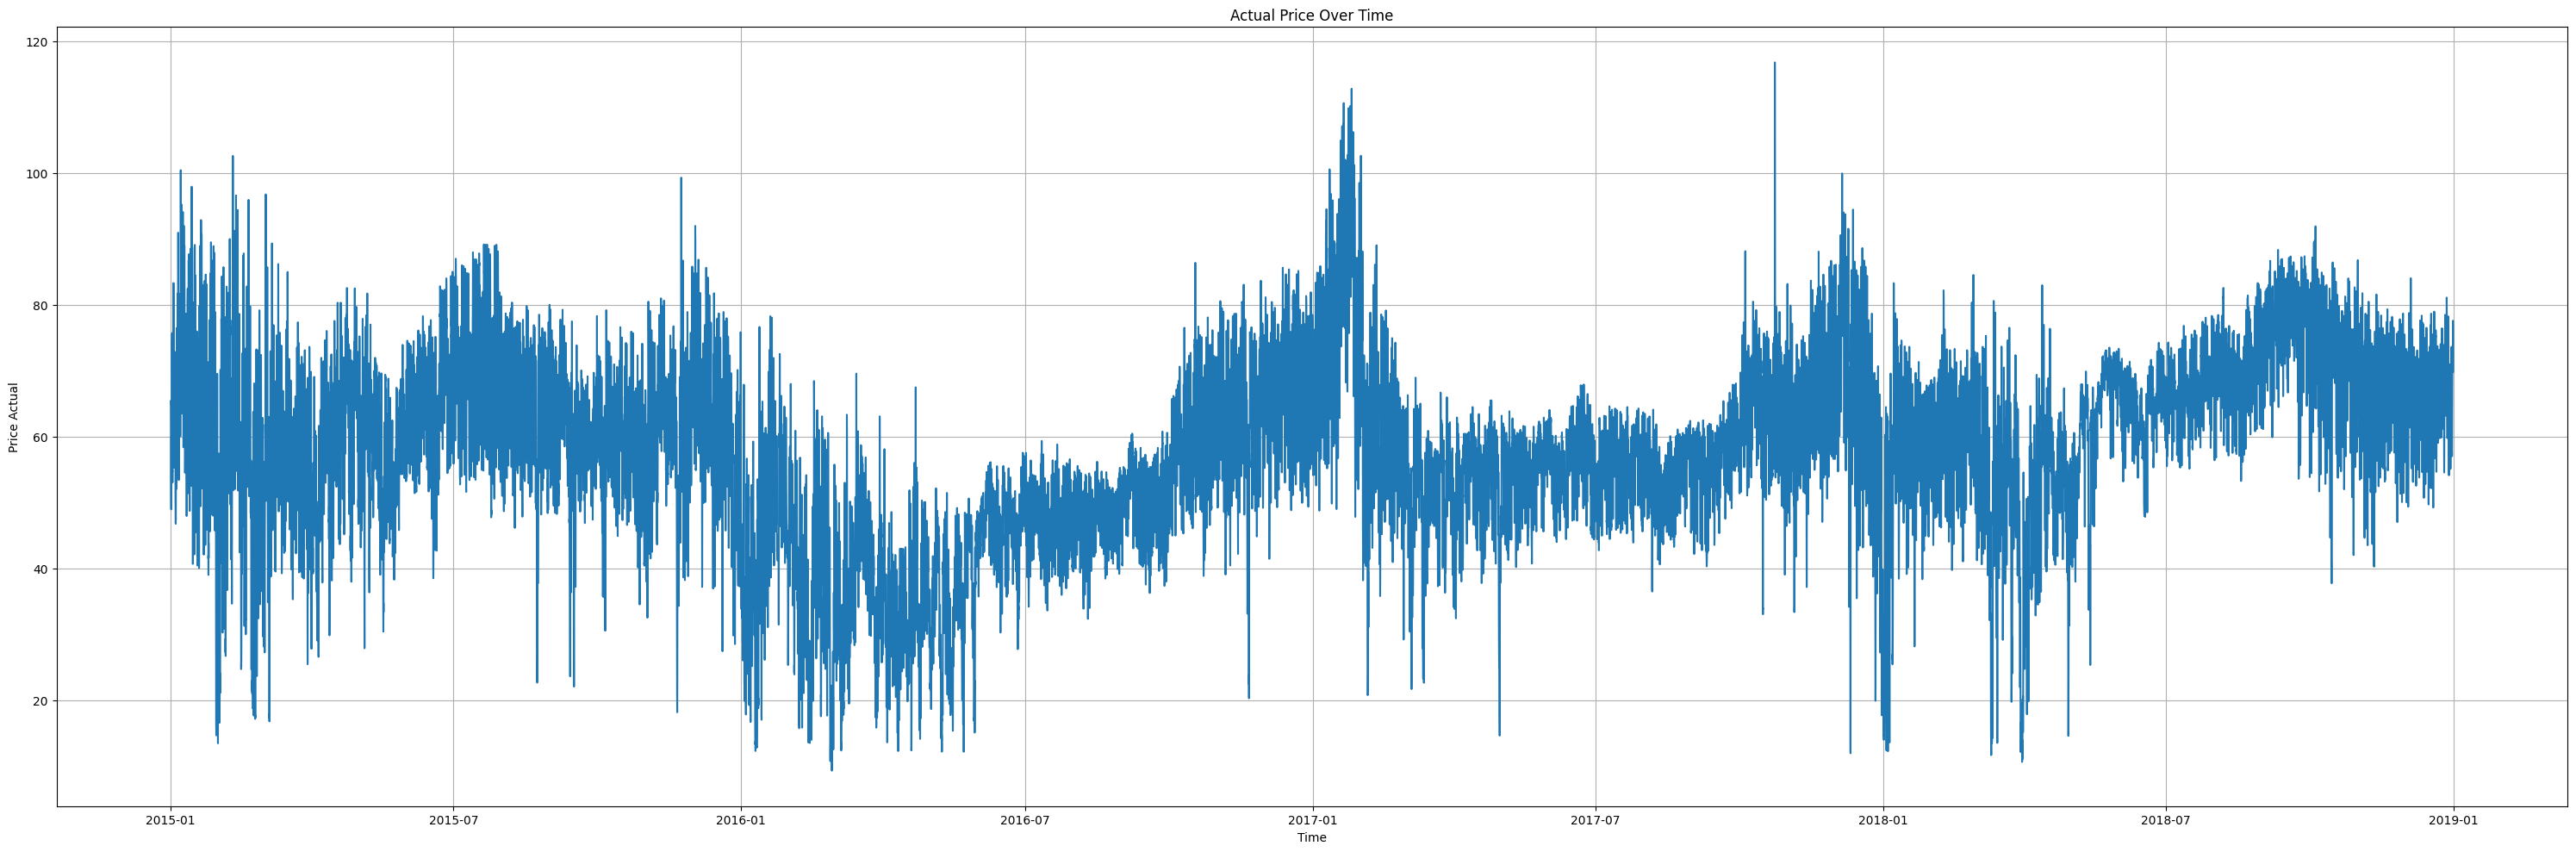

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'time' column to datetime objects
df['time'] = pd.to_datetime(df['time'], utc=True)

# Plot 'price actual' over time
plt.figure(figsize=(30, 10))
sns.lineplot(x='time', y='price actual', data=df)
plt.title('Actual Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price Actual')
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# Drop columns that would cause data leakage to the RNN
columns_to_drop = [
    'total load actual',
    'price day ahead',
    'forecast solar day ahead',
    'forecast wind offshore eday ahead',
    'forecast wind onshore day ahead',
    'total load forecast',
    'generation hydro pumped storage aggregated' # Identified as all null from df.info()
]

df = df.drop(columns=columns_to_drop, errors='ignore')

df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 22 columns):
 #   Column                                       Non-Null Count  Dtype              
---  ------                                       --------------  -----              
 0   time                                         35064 non-null  datetime64[ns, UTC]
 1   generation biomass                           35045 non-null  float64            
 2   generation fossil brown coal/lignite         35046 non-null  float64            
 3   generation fossil coal-derived gas           35046 non-null  float64            
 4   generation fossil gas                        35046 non-null  float64            
 5   generation fossil hard coal                  35046 non-null  float64            
 6   generation fossil oil                        35045 non-null  float64            
 7   generation fossil oil shale                  35046 non-null  float64            
 8   generation fossil peat    

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,price actual
0,2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,65.41
1,2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,64.92
2,2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,64.48
3,2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,59.32
4,2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,56.04


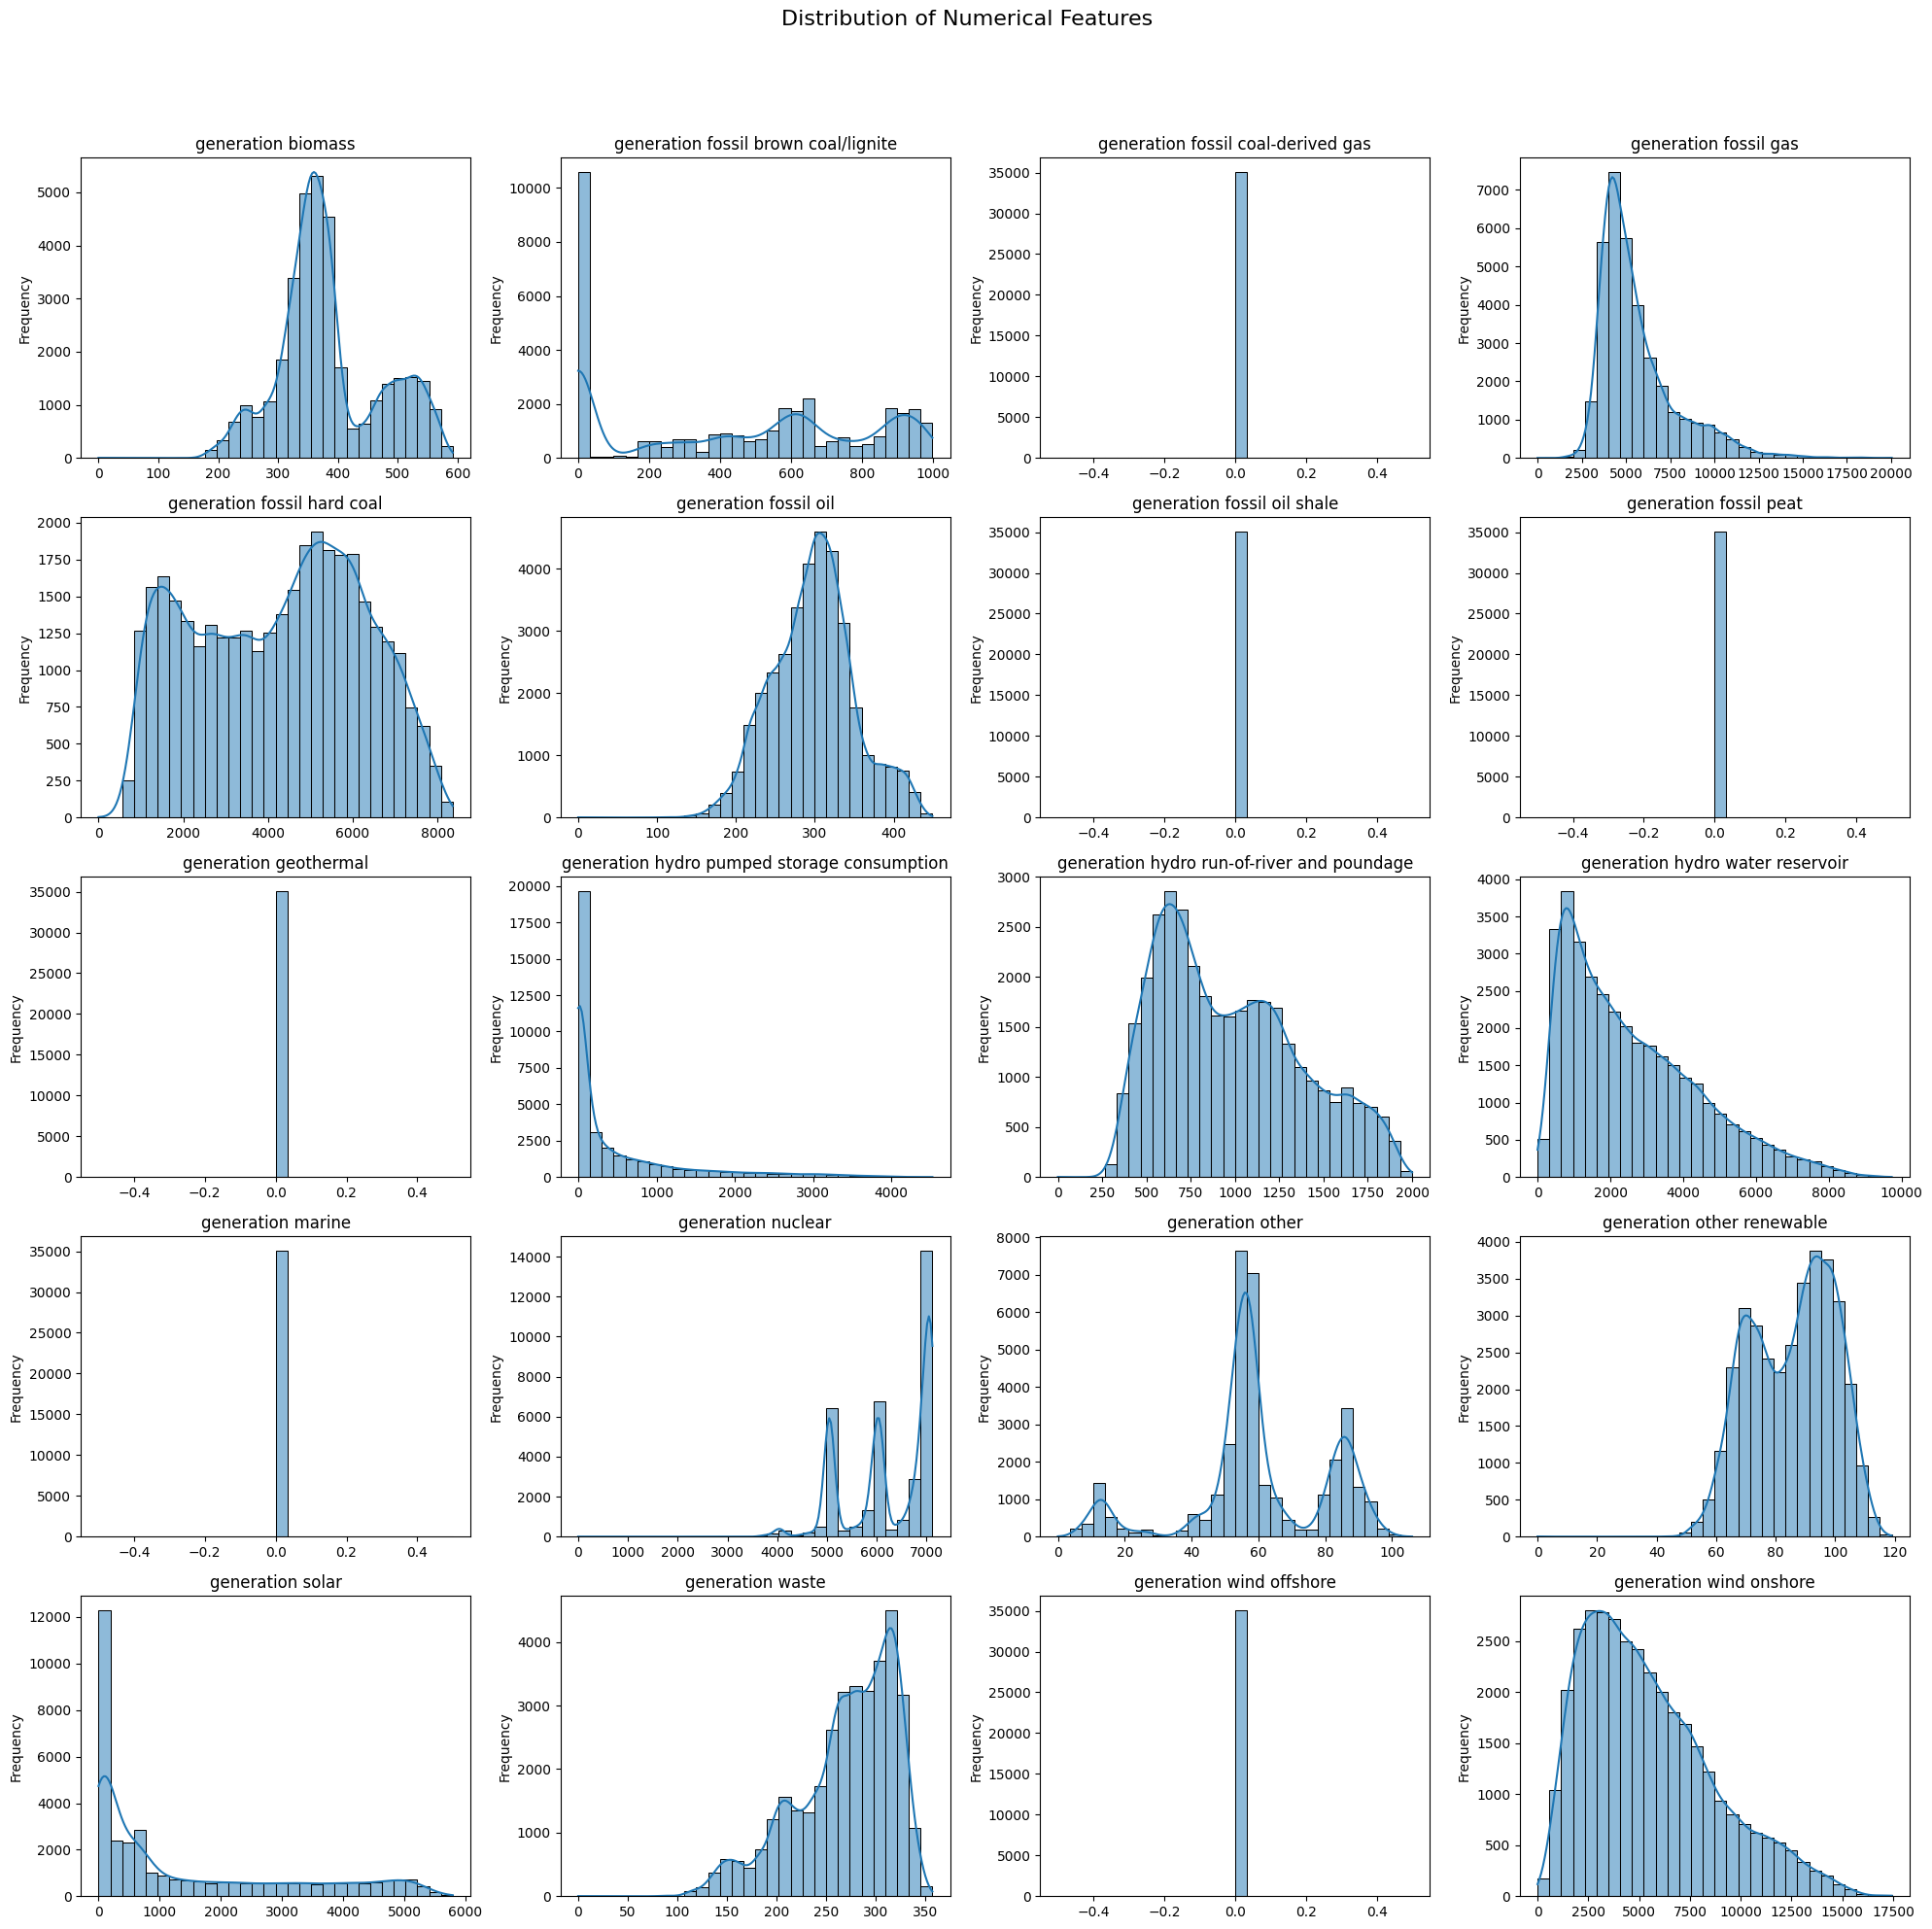

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for visualization
numerical_features = [col for col in df.columns if col not in ['time', 'price actual'] and df[col].dtype == 'float64']

num_features = len(numerical_features)
num_cols = 4 # Number of plots per row
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('Distribution of Numerical Features', y=1.02, fontsize=16)

for i, feature in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(feature)
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

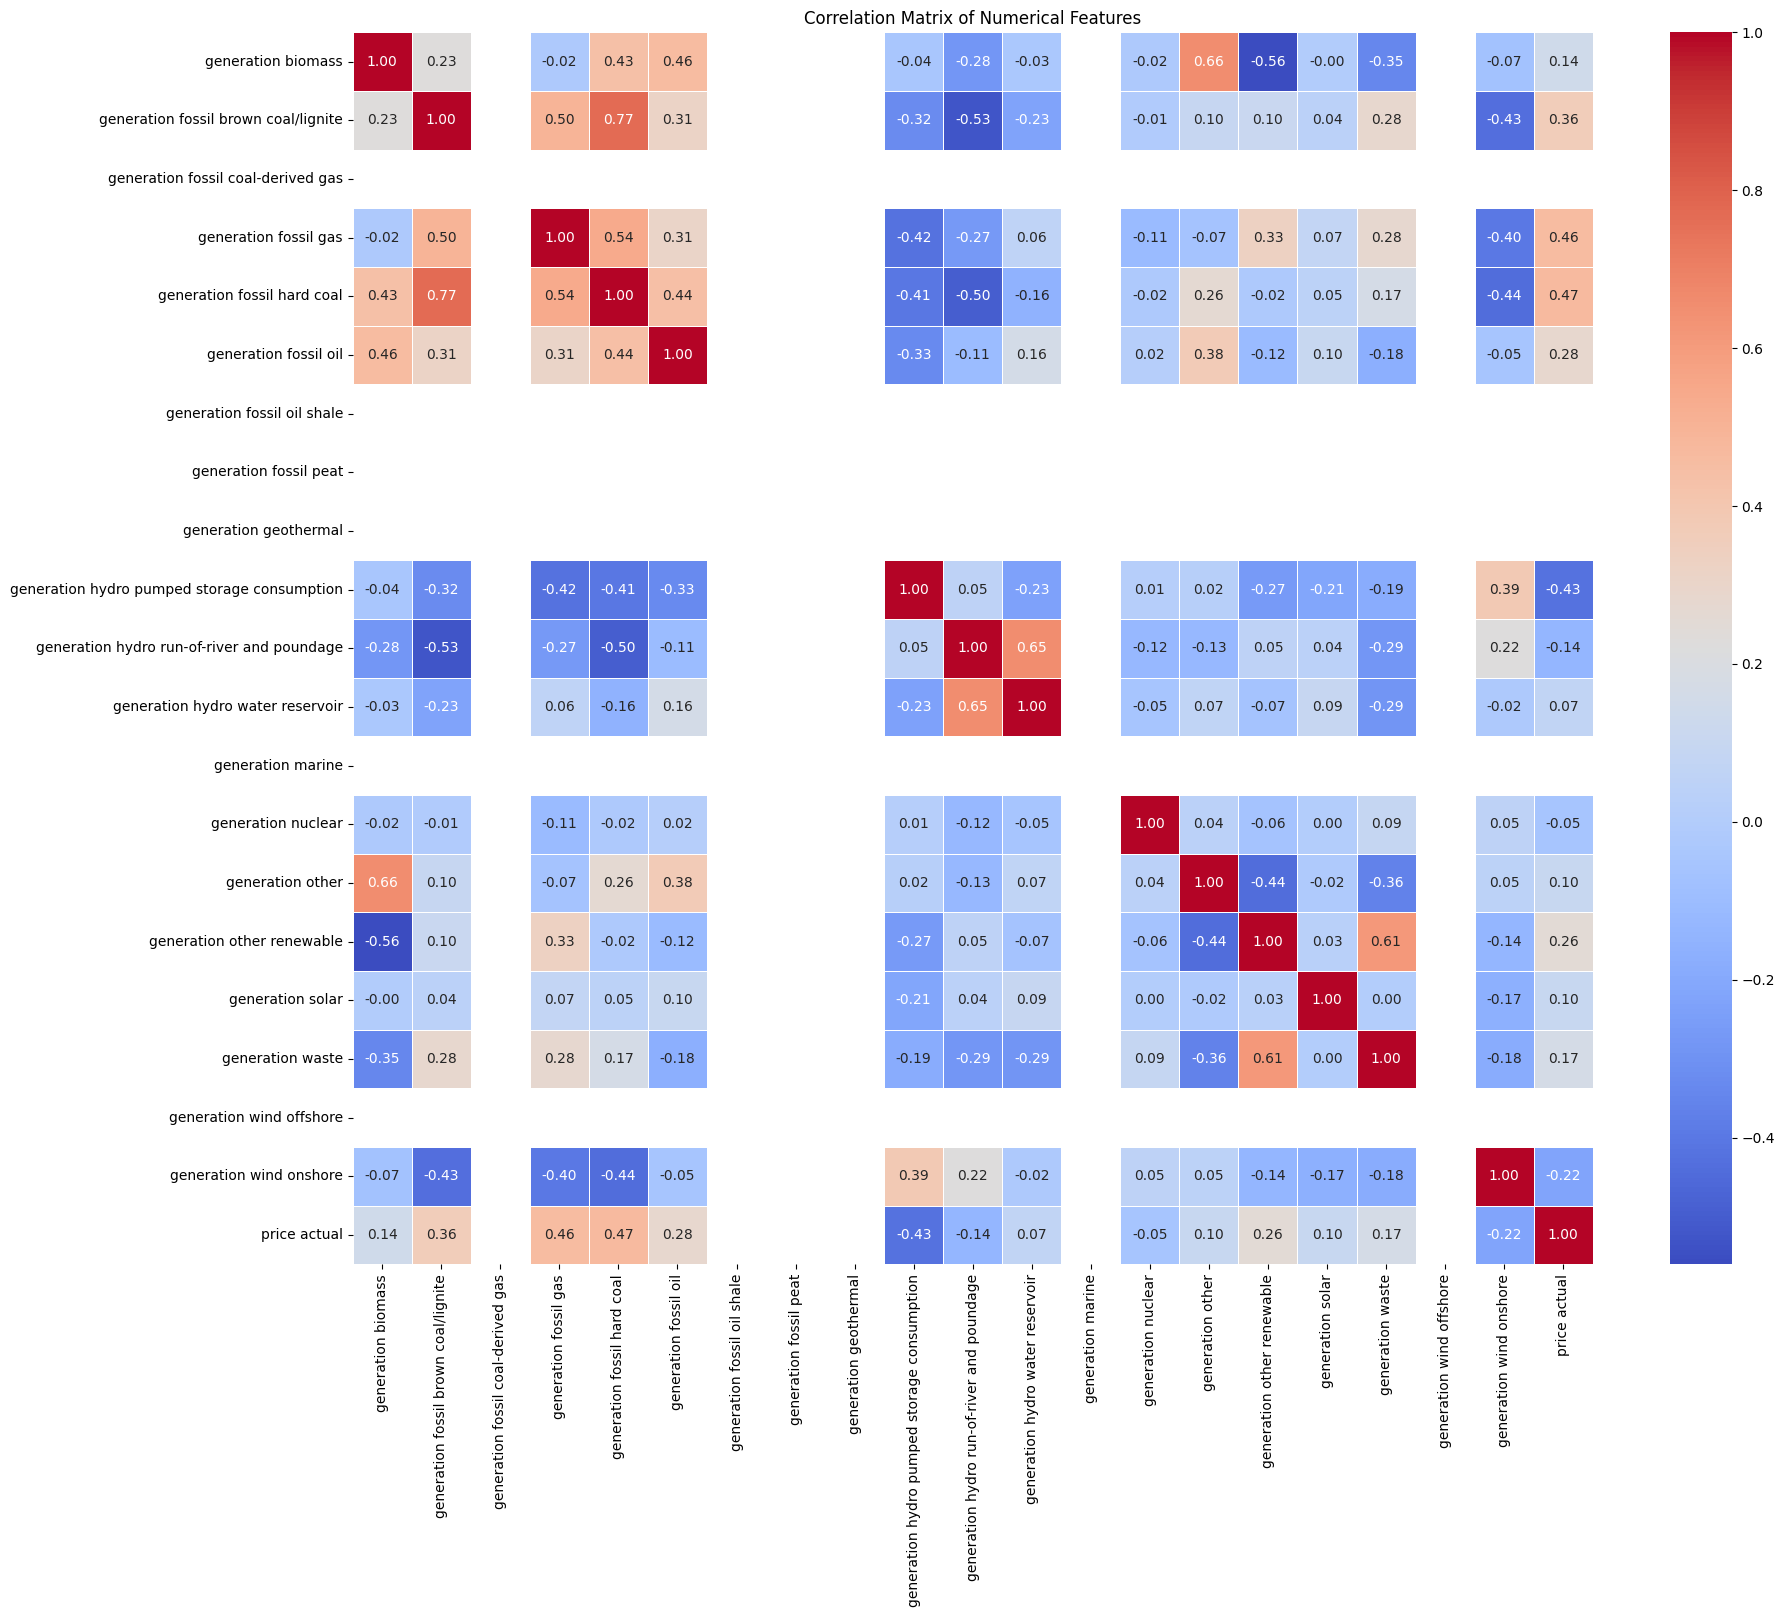

In [62]:
# Select only numerical columns for correlation calculation
df_numerical = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = df_numerical.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Preprocessing

In [41]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Handle remaining missing values in the features
for col in df.columns:
    if df[col].dtype == 'float64' and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Sort by time to ensure chronological splitting
df = df.sort_values(by='time').reset_index(drop=True)

# Define features and target
features = [col for col in df.columns if col not in ['time', 'price actual']]
X = df[features]
y = df['price actual']

# Split data into training, validation, and test sets chronologically
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
# Test size will be rest

X_train, X_val, X_test = X[0:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[0:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Scale the features and target using MinMaxScaler (to help the RNN)
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Function to create sequences for RNN
def create_sequences(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Use 24 hours of data to predict the next hour
time_steps = 24

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print(f"\nShape of sequences after creation (time_steps={time_steps}):")
print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}, y_val_seq shape: {y_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

X_train shape: (24544, 20), y_train shape: (24544,)
X_val shape: (5259, 20), y_val shape: (5259,)
X_test shape: (5261, 20), y_test shape: (5261,)

Shape of sequences after creation (time_steps=24):
X_train_seq shape: (24520, 24, 20), y_train_seq shape: (24520, 1)
X_val_seq shape: (5235, 24, 20), y_val_seq shape: (5235, 1)
X_test_seq shape: (5237, 24, 20), y_test_seq shape: (5237, 1)


Model Definition

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert numpy arrays to PyTorch tensors and move to device
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).to(device)

# Define the RNN model in PyTorch
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        # batch_first=True means input/output tensors are (batch, seq, feature)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='relu') # ReLU activation
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(device)
        # Pass through RNN layer
        out, _ = self.rnn(x, h0)
        # Take the output of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Model parameters
input_size = X_train_seq.shape[2] # Number of features
hidden_size = 50
output_size = 1 # Predicting 'price actual'

model_rnn = RNN(input_size, hidden_size, output_size).to(device)

# Define Loss and Optimizer
criterion = nn.MSELoss() # Mean Squared Error
optimizer = optim.Adam(model_rnn.parameters(), lr=0.001)

print("PyTorch RNN Model Structure:")
print(model_rnn)


Using device: cpu
PyTorch RNN Model Structure:
RNN(
  (rnn): RNN(20, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


Training

Epoch [1/20], Train Loss: 0.0134, Validation Loss: 0.0317
Best model saved with validation loss: 0.0317
Epoch [2/20], Train Loss: 0.0073, Validation Loss: 0.0296
Best model saved with validation loss: 0.0296
Epoch [3/20], Train Loss: 0.0069, Validation Loss: 0.0274
Best model saved with validation loss: 0.0274
Epoch [4/20], Train Loss: 0.0067, Validation Loss: 0.0255
Best model saved with validation loss: 0.0255
Epoch [5/20], Train Loss: 0.0066, Validation Loss: 0.0242
Best model saved with validation loss: 0.0242
Epoch [6/20], Train Loss: 0.0065, Validation Loss: 0.0241
Best model saved with validation loss: 0.0241
Epoch [7/20], Train Loss: 0.0066, Validation Loss: 0.0214
Best model saved with validation loss: 0.0214
Epoch [8/20], Train Loss: 0.0066, Validation Loss: 0.0197
Best model saved with validation loss: 0.0197
Epoch [9/20], Train Loss: 0.0066, Validation Loss: 0.0226
Epoch [10/20], Train Loss: 0.0064, Validation Loss: 0.0206
Epoch [11/20], Train Loss: 0.0064, Validation Loss:

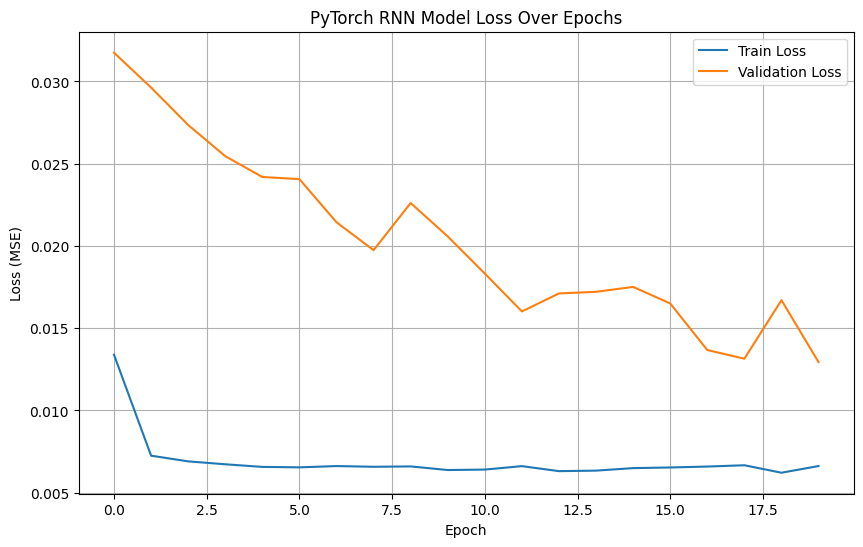


Loaded best model for evaluation.


In [43]:
# Training the PyTorch RNN model
num_epochs = 20
batch_size = 32

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    model_rnn.train()
    epoch_train_loss = 0
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i + batch_size]
        batch_y = y_train_tensor[i:i + batch_size]

        optimizer.zero_grad()
        outputs = model_rnn(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = epoch_train_loss / len(X_train_tensor)
    train_losses.append(avg_train_loss)

    # Validation phase
    model_rnn.eval()
    with torch.no_grad():
        val_outputs = model_rnn(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()
        val_losses.append(val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Validation Loss: {val_loss:.4f}')

    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_rnn.state_dict()
        print(f"Best model saved with validation loss: {best_val_loss:.4f}")

# Plotting training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('PyTorch RNN Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Load the best model state dictionary for evaluation
if best_model_state:
    model_rnn.load_state_dict(best_model_state)
    print("\nLoaded best model for evaluation.")
else:
    print("No best model found. Using the model from the last epoch.")

Evaluation

In [46]:
# Evaluate the model on the test set
model_rnn.eval()
with torch.no_grad():
    y_test_pred_scaled = model_rnn(X_test_tensor).cpu().numpy()

# Inverse transform the scaled predictions and actual values to original scale
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())

# Calculate MSE on the original scale
test_mse = mean_squared_error(y_test_actual, y_test_pred)
print(f"\nMean Squared Error on Test Set (original scale): {test_mse:.4f}")

print("\nSample Test Predictions vs Actuals:")
results_df = pd.DataFrame({'Actual': y_test_actual.flatten(), 'Predicted': y_test_pred.flatten()})
display(results_df.head(10))


Mean Squared Error on Test Set (original scale): 82.4077

Sample Test Predictions vs Actuals:


,Actual,Predicted
0,60.799999,57.917274
1,70.190002,57.998310
2,70.190002,63.196117
3,67.309998,60.066284
4,68.050003,58.918812
5,65.970001,55.321426
6,57.809998,56.486115
7,56.879997,55.665394
8,57.400002,55.621334
9,57.920002,56.789249


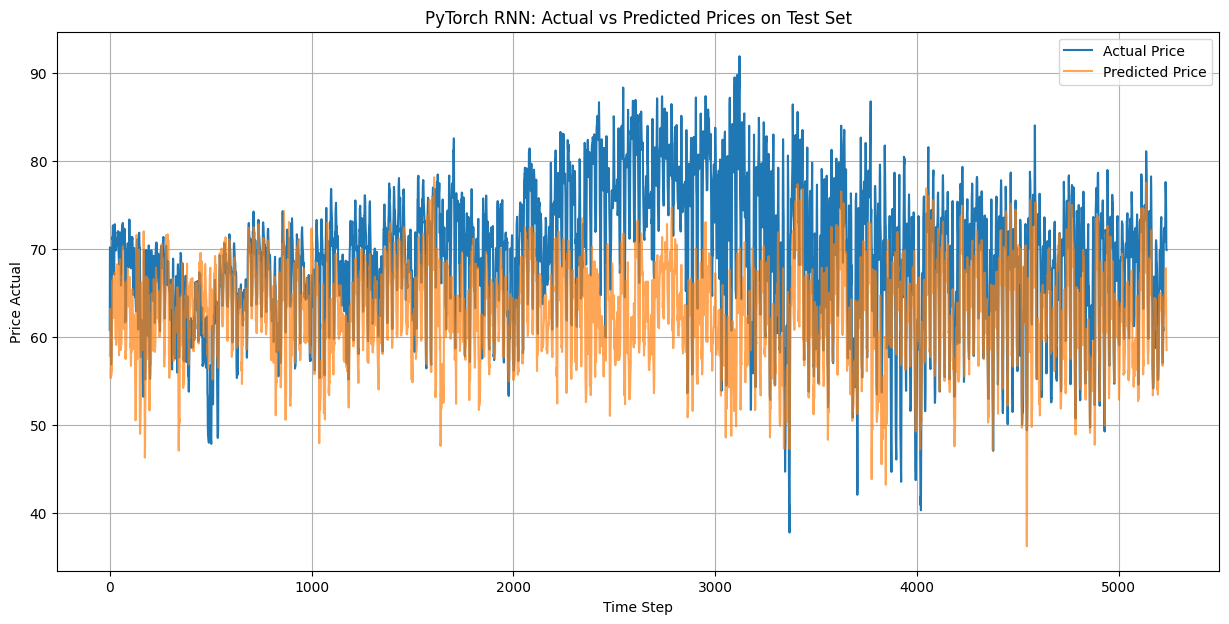

In [47]:
# Visualize predictions vs actuals for the test set
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(y_test_pred, label='Predicted Price', alpha=0.7)
plt.title('PyTorch RNN: Actual vs Predicted Prices on Test Set')
plt.xlabel('Time Step')
plt.ylabel('Price Actual')
plt.legend()
plt.grid(True)
plt.show()

#2.1
##Implement your RNN either using an existing framework OR you can implement your own RNN cell structure. In either case, describe the structure of your RNN and the activation functions you are using for each time step and in the output layer. Define a metric you will use to measure the performance of your model (NOTE: Performance should be measured both for the validation set and the test set).

I used PyTorch to implement my RNN. The input layer takes a sequence of features. The input size is the number of features (in this case 20) and the number of sequences is 24 for the past 24 hours. In the recurrent layer, we have a hidden size of 50 and use ReLU as the activation function within the RNN. For the output layer, I use a dense linear layer with a single output to predict the price actual variable. There is no activation function on the output as this is a regression task. The performance metric we will be using is MSE as it is the average of square of errors. This is good as it penalizes larger errors more than smaller ones. The optimizer I chose to use was adam from pytorch. Features were scaled with a min max scaler during training and then the inverse transform was done for evaluation after training to make sense of the results.

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the LSTM model in PyTorch
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # batch_first=True means input/output tensors are (batch, seq, feature)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Pass through LSTM layer
        out, _ = self.lstm(x, (h0, c0))
        # Take the output of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Model parameters
input_size = X_train_seq.shape[2]
hidden_size = 50
output_size = 1
num_layers = 1 # Using a single LSTM layer

model_lstm = LSTM(input_size, hidden_size, output_size, num_layers).to(device)

# Define Loss and Optimizer
criterion = nn.MSELoss() # Mean Squared Error
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.001)

print("PyTorch LSTM Model Structure:")
print(model_lstm)

Using device: cpu
PyTorch LSTM Model Structure:
LSTM(
  (lstm): LSTM(20, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


Epoch [1/20], Train Loss: 0.0066, Validation Loss: 0.0197
Best LSTM model saved with validation loss: 0.0197
Epoch [2/20], Train Loss: 0.0063, Validation Loss: 0.0179
Best LSTM model saved with validation loss: 0.0179
Epoch [3/20], Train Loss: 0.0064, Validation Loss: 0.0155
Best LSTM model saved with validation loss: 0.0155
Epoch [4/20], Train Loss: 0.0064, Validation Loss: 0.0146
Best LSTM model saved with validation loss: 0.0146
Epoch [5/20], Train Loss: 0.0065, Validation Loss: 0.0139
Best LSTM model saved with validation loss: 0.0139
Epoch [6/20], Train Loss: 0.0065, Validation Loss: 0.0135
Best LSTM model saved with validation loss: 0.0135
Epoch [7/20], Train Loss: 0.0065, Validation Loss: 0.0125
Best LSTM model saved with validation loss: 0.0125
Epoch [8/20], Train Loss: 0.0067, Validation Loss: 0.0120
Best LSTM model saved with validation loss: 0.0120
Epoch [9/20], Train Loss: 0.0065, Validation Loss: 0.0118
Best LSTM model saved with validation loss: 0.0118
Epoch [10/20], Trai

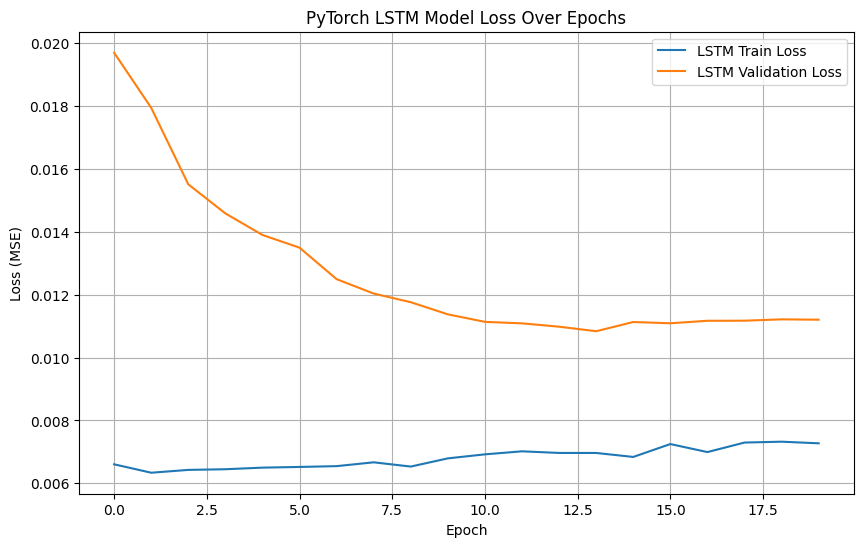


Loaded best LSTM model for evaluation.


In [53]:
# Training the PyTorch LSTM model
num_epochs = 20
batch_size = 32

train_losses_lstm = []
val_losses_lstm = []
best_val_loss_lstm = float('inf')
best_model_state_lstm = None

for epoch in range(num_epochs):
    model_lstm.train()
    epoch_train_loss = 0
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i + batch_size]
        batch_y = y_train_tensor[i:i + batch_size]

        optimizer_lstm.zero_grad()
        outputs = model_lstm(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_lstm.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = epoch_train_loss / len(X_train_tensor)
    train_losses_lstm.append(avg_train_loss)

    # Validation phase
    model_lstm.eval()
    with torch.no_grad():
        val_outputs = model_lstm(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()
        val_losses_lstm.append(val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Validation Loss: {val_loss:.4f}')

    # Save the best model
    if val_loss < best_val_loss_lstm:
        best_val_loss_lstm = val_loss
        best_model_state_lstm = model_lstm.state_dict()
        print(f"Best LSTM model saved with validation loss: {best_val_loss_lstm:.4f}")

# Plotting training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses_lstm, label='LSTM Train Loss')
plt.plot(val_losses_lstm, label='LSTM Validation Loss')
plt.title('PyTorch LSTM Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Load the best model state dictionary for evaluation
if best_model_state_lstm:
    model_lstm.load_state_dict(best_model_state_lstm)
    print("\nLoaded best LSTM model for evaluation.")
else:
    print("No best LSTM model found. Using the model from the last epoch.")

In [54]:
# Evaluate the LSTM model on the test set
model_lstm.eval()
with torch.no_grad():
    y_test_pred_scaled_lstm = model_lstm(X_test_tensor).cpu().numpy()

# Inverse transform the scaled predictions and actual values to original scale
y_test_pred_lstm = scaler_y.inverse_transform(y_test_pred_scaled_lstm)
y_test_actual_lstm = scaler_y.inverse_transform(y_test_tensor.cpu().numpy()) # Use the same actual values as RNN evaluation

# Calculate MSE on the original scale
test_mse_lstm = mean_squared_error(y_test_actual_lstm, y_test_pred_lstm)
print(f"\nMean Squared Error on Test Set (original scale) for LSTM: {test_mse_lstm:.4f}")

print("\nSample Test Predictions vs Actuals (LSTM):")
results_df_lstm = pd.DataFrame({'Actual': y_test_actual_lstm.flatten(), 'Predicted': y_test_pred_lstm.flatten()})
display(results_df_lstm.head(10))


Mean Squared Error on Test Set (original scale) for LSTM: 151.0127

Sample Test Predictions vs Actuals (LSTM):


,Actual,Predicted
0,60.799999,57.917793
1,70.190002,59.304127
2,70.190002,62.661819
3,67.309998,60.831425
4,68.050003,58.671268
5,65.970001,56.201122
6,57.809998,55.466026
7,56.879997,55.194202
8,57.400002,55.244064
9,57.920002,56.203369


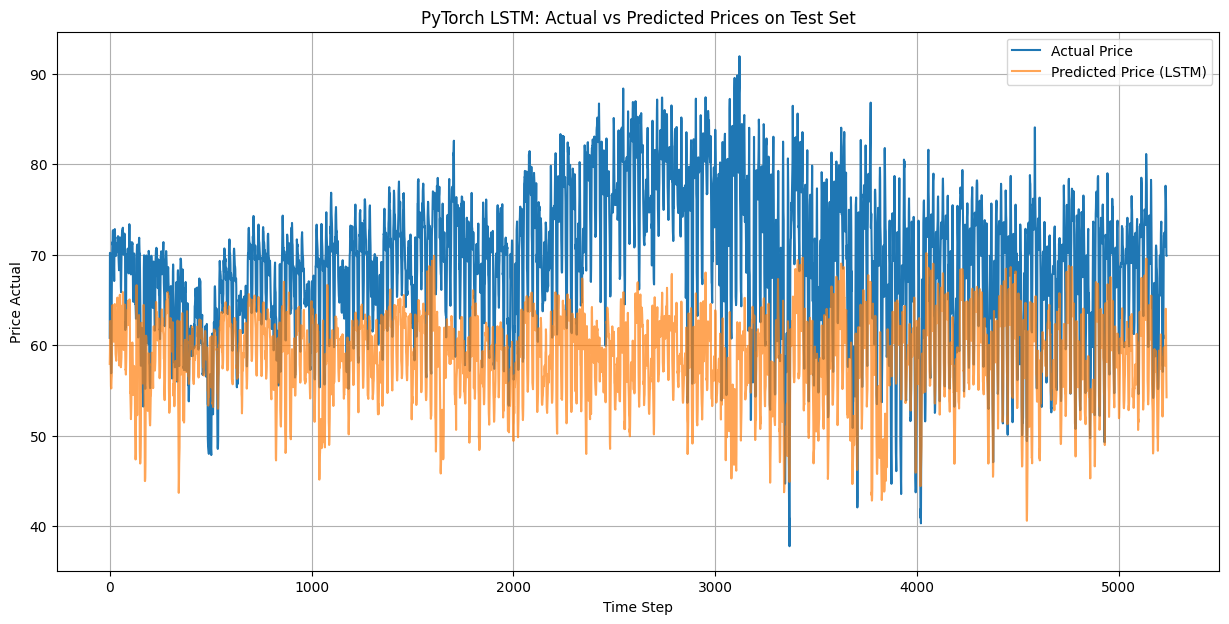

In [55]:
# Visualize LSTM predictions vs actuals for the test set
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual_lstm, label='Actual Price')
plt.plot(y_test_pred_lstm, label='Predicted Price (LSTM)', alpha=0.7)
plt.title('PyTorch LSTM: Actual vs Predicted Prices on Test Set')
plt.xlabel('Time Step')
plt.ylabel('Price Actual')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the GRU model in PyTorch
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # batch_first=True means input/output tensors are (batch, seq, feature)
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Pass through GRU layer
        out, _ = self.gru(x, h0)
        # Take the output of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Model parameters
input_size = X_train_seq.shape[2]
hidden_size = 50
output_size = 1
num_layers = 1 # Using a single GRU layer

model_gru = GRU(input_size, hidden_size, output_size, num_layers).to(device)

# Define Loss and Optimizer
criterion = nn.MSELoss() # Mean Squared Error
optimizer_gru = optim.Adam(model_gru.parameters(), lr=0.001)

print("PyTorch GRU Model Structure:")
print(model_gru)

Using device: cpu
PyTorch GRU Model Structure:
GRU(
  (gru): GRU(20, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


Epoch [1/20], Train Loss: 0.0065, Validation Loss: 0.0203
Best GRU model saved with validation loss: 0.0203
Epoch [2/20], Train Loss: 0.0063, Validation Loss: 0.0195
Best GRU model saved with validation loss: 0.0195
Epoch [3/20], Train Loss: 0.0062, Validation Loss: 0.0185
Best GRU model saved with validation loss: 0.0185
Epoch [4/20], Train Loss: 0.0061, Validation Loss: 0.0188
Epoch [5/20], Train Loss: 0.0061, Validation Loss: 0.0167
Best GRU model saved with validation loss: 0.0167
Epoch [6/20], Train Loss: 0.0060, Validation Loss: 0.0145
Best GRU model saved with validation loss: 0.0145
Epoch [7/20], Train Loss: 0.0060, Validation Loss: 0.0139
Best GRU model saved with validation loss: 0.0139
Epoch [8/20], Train Loss: 0.0061, Validation Loss: 0.0127
Best GRU model saved with validation loss: 0.0127
Epoch [9/20], Train Loss: 0.0061, Validation Loss: 0.0124
Best GRU model saved with validation loss: 0.0124
Epoch [10/20], Train Loss: 0.0062, Validation Loss: 0.0119
Best GRU model save

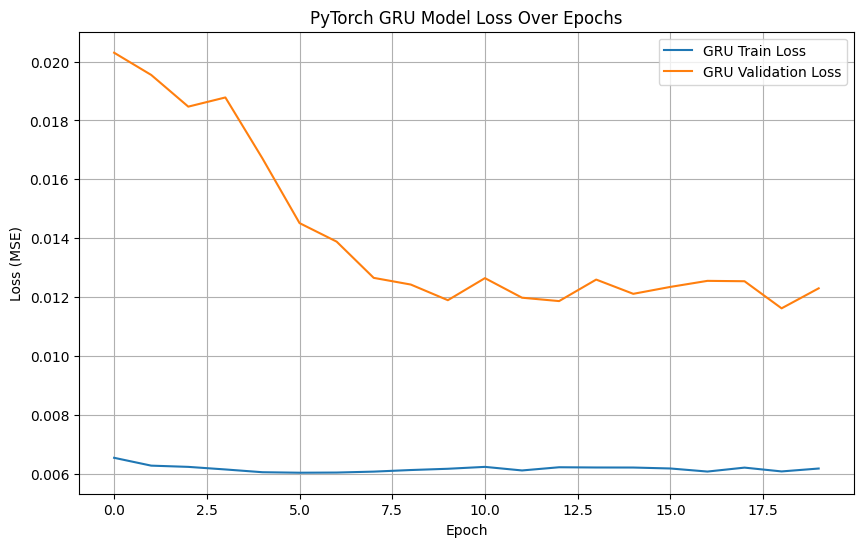


Loaded best GRU model for evaluation.


In [58]:
# Training the PyTorch GRU model
num_epochs = 20
batch_size = 32

train_losses_gru = []
val_losses_gru = []
best_val_loss_gru = float('inf')
best_model_state_gru = None

for epoch in range(num_epochs):
    model_gru.train()
    epoch_train_loss = 0
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i + batch_size]
        batch_y = y_train_tensor[i:i + batch_size]

        optimizer_gru.zero_grad()
        outputs = model_gru(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_gru.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = epoch_train_loss / len(X_train_tensor)
    train_losses_gru.append(avg_train_loss)

    # Validation phase
    model_gru.eval()
    with torch.no_grad():
        val_outputs = model_gru(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()
        val_losses_gru.append(val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Validation Loss: {val_loss:.4f}')

    # Save the best model
    if val_loss < best_val_loss_gru:
        best_val_loss_gru = val_loss
        best_model_state_gru = model_gru.state_dict()
        print(f"Best GRU model saved with validation loss: {best_val_loss_gru:.4f}")

# Plotting training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses_gru, label='GRU Train Loss')
plt.plot(val_losses_gru, label='GRU Validation Loss')
plt.title('PyTorch GRU Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Load the best model state dictionary for evaluation
if best_model_state_gru:
    model_gru.load_state_dict(best_model_state_gru)
    print("\nLoaded best GRU model for evaluation.")
else:
    print("No best GRU model found. Using the model from the last epoch.")

In [59]:
# Evaluate the GRU model on the test set
model_gru.eval()
with torch.no_grad():
    y_test_pred_scaled_gru = model_gru(X_test_tensor).cpu().numpy()

# Inverse transform the scaled predictions and actual values to original scale
y_test_pred_gru = scaler_y.inverse_transform(y_test_pred_scaled_gru)
y_test_actual_gru = scaler_y.inverse_transform(y_test_tensor.cpu().numpy()) # Use the same actual values as previous evaluations

# Calculate MSE on the original scale
test_mse_gru = mean_squared_error(y_test_actual_gru, y_test_pred_gru)
print(f"\nMean Squared Error on Test Set (original scale) for GRU: {test_mse_gru:.4f}")

print("\nSample Test Predictions vs Actuals (GRU):")
results_df_gru = pd.DataFrame({'Actual': y_test_actual_gru.flatten(), 'Predicted': y_test_pred_gru.flatten()})
display(results_df_gru.head(10))


Mean Squared Error on Test Set (original scale) for GRU: 90.8866

Sample Test Predictions vs Actuals (GRU):


,Actual,Predicted
0,60.799999,63.010620
1,70.190002,63.600506
2,70.190002,65.253311
3,67.309998,63.234249
4,68.050003,61.885048
5,65.970001,59.968914
6,57.809998,59.223450
7,56.879997,58.777599
8,57.400002,58.728199
9,57.920002,59.098625


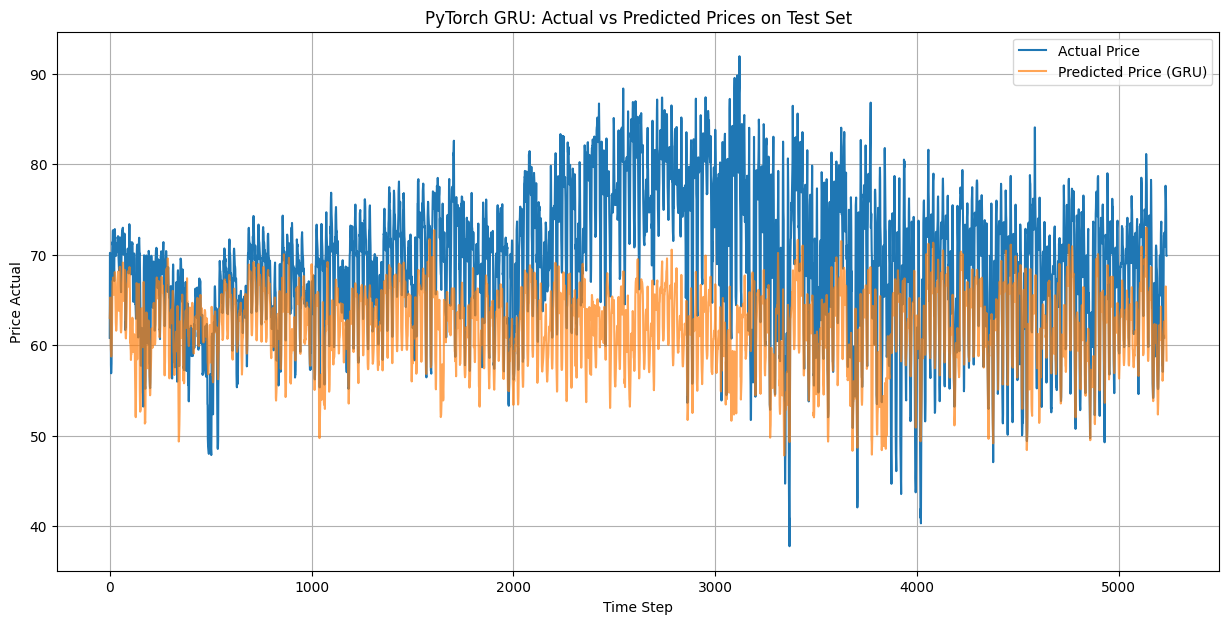

In [60]:
# Visualize GRU predictions vs actuals for the test set
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual_gru, label='Actual Price')
plt.plot(y_test_pred_gru, label='Predicted Price (GRU)', alpha=0.7)
plt.title('PyTorch GRU: Actual vs Predicted Prices on Test Set')
plt.xlabel('Time Step')
plt.ylabel('Price Actual')
plt.legend()
plt.grid(True)
plt.show()

#2.2

## Update your network from part 1 with first an LSTM and then a GRU based cell structure (You can treat both as 2 separate implementations). Re-do the training and performance evaluation. What are the major differences you notice? Why do you think those differences exist between the 3 implementations (basic RNN, LSTM and GRU)?

I used PyTorch to implement the LSTM and GRU. When redoing the training and performance evaluation, we can see that the LSTM and GRU do better than the RNN on validation performance than the RNN. The biggest difference in the performance for the three models is on the test evaluation. On test evaluation, the LSTM performs the worst and the RNN actually performs the best. This is unexpected as the LSTM and GRU are expected to be better models than the RNN, however this might be attrivuted to a distribution shift caused by time. While they perform better on the validation than the RNN, they likely pick up more on the distribution for that time period/the signal behind that more than a general trend. Therefore, since even more time passes when we get to the test set, if there is a distribution shift, it can cause the models that picked up on the specific signals of the training time period to be worse compared to the RNN.

Additionally, because LSTM's and GRU's use gates to store long range dependencies, and in this problem I am only using the last 24 hours to predict the next price of energy, the extra gates add unnecessary complexity which can affect the learning. Therefore, it makes sense for both reasons that the LSTM performs the worst as it has the most gates and can attentuate on the short term signals of a time period more.

Lastly, the advantage that GRU's and LSTM's have with vanishing gradients is negligible due to the small time step that we are predicting with.

#2.3
##  Can you use the traditional feed-forward network to solve the same problem. Why or why not?

Technically, you can use traditional feed-forward networks to solve this problem. By flattening the sequences into a single array, you can technically try to solve the problem with a sequence of values. The problem is that it would be unable to understand order or temporal dependencies. When you have large sequence lengths or time steps the number of features can dramatically blow up causing the traditional feed-forward network to struggle. Additionally since there is no internal hidden state updating, feed forward neural networks cannot learn long term dependencies as they do not have any sort of internal memory mechanism that something like an RNN would have. In a smaller problem like energy price forcasting these models might not be terrible due to them being noiser and the time step sizes usually not being that long.

# 3. Implementing Word Embeddings

## Use a pre-trained word embedding model (Word2Vec, GloVe, FastText, or BERT embeddings).
• Provide a comparative discussion on why you chose this embedding over others.

I chose to implement the BERT embeddings. BERT converts each word into a dense vector that also captures its semantic meaning and context. Compared to Word2Vec which provides a single context-independent embedding for each word (meaning there are not different vectors for different meanings), BERT can handle context. Additionally bert naturally handes unknown words where Word2Vec does not. GloVe uses static embeddings so it also does not adapt to context. It also cannot handle unknown words, so it has the same issues as Word2Vec. Similarly FastText also has static embeddings giving it the same issues as Word2Vec. Since BERT can provide contextual embeddings and is able to deal with unknown words, I have chosen to use BERT as my vector embedding model.

In [78]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load Sentence-BERT model
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Sentence-BERT model loaded successfully.")

def get_embedding(text, model):
    return model.encode(text)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence-BERT model loaded successfully.


In [80]:
# Dynamic user input for tokens
word1 = input("Enter first word: ")
word2 = input("Enter second word: ")

embedding1 = get_embedding(word1, model)
embedding2 = get_embedding(word2, model)

print(f"\nEmbedding for '{word1}':")
print(embedding1)

print(f"\nEmbedding for '{word2}':")
print(embedding2)

Enter first word: yes
Enter second word: no

Embedding for 'yes':
[-1.17357068e-01  6.45193737e-04  2.93863863e-02  2.75004990e-02
  1.49841653e-02 -2.22335029e-02  1.37595609e-01  4.21503186e-02
 -5.16264439e-02 -1.03321068e-01  2.54864451e-02  6.04320057e-02
 -4.98130284e-02  6.91498220e-02  5.61653189e-02  6.84683174e-02
 -7.22021312e-02 -4.79345508e-02 -7.85273015e-02 -1.48189161e-02
 -1.05329782e-01 -2.06466634e-02 -7.44486898e-02  2.53839027e-02
 -5.33150183e-03 -7.56755052e-03  1.52316294e-03  6.22392409e-02
  1.45831220e-02 -8.64731744e-02 -2.37709004e-02 -2.09264178e-02
  6.36029243e-02  2.07128804e-02  3.93299833e-02  7.35710259e-04
 -4.35553938e-02 -1.57661568e-02  2.96495315e-02  2.56786849e-02
 -3.79458666e-02 -6.46495596e-02 -4.87549715e-02  2.25528963e-02
  2.90850382e-02  1.91796552e-02 -8.16809162e-02  5.59690632e-02
  6.23234026e-02 -6.14564084e-02 -3.75560522e-02 -1.51355863e-02
  4.29288112e-02 -1.60223749e-02  1.35244370e-01 -3.32894213e-02
  2.65405662e-02  4.8478

BERT naturally handes OOV by splitting unknown words into subwords by using WordPiece tokenization. Therefore, there is no need to do anything manually for handling OOV cases.

## Cosine Similarity Computation

In [ ]:
import numpy as np

def cosine_similarity(embedding1, embedding2):
    # Calculate the dot product of the two embeddings
    dot_product = np.dot(embedding1, embedding2)
    # Calculate the magnitude of each embedding
    norm_e1 = np.linalg.norm(embedding1)
    norm_e2 = np.linalg.norm(embedding2)

    # Handle division by zero if one of the norms is zero
    if norm_e1 == 0 or norm_e2 == 0:
        return 0.0

    # Calculate cosine similarity
    similarity = dot_product / (norm_e1 * norm_e2)
    return similarity

# Calculate cosine similarity for the two embeddings we generated
sim = cosine_similarity(embedding1, embedding2)

print(f"\nCosine Similarity between '{word1}' and '{word2}': {sim:.4f}")


Cosine Similarity between 'yes' and 'no': 0.7335


bacth processing

In [82]:
pairs = []

n = int(input("How many word pairs do you want to compare? "))

for i in range(n):
    w1 = input(f"Pair {i+1} - Enter first word: ")
    w2 = input(f"Pair {i+1} - Enter second word: ")
    pairs.append((w1, w2))

How many word pairs do you want to compare? 5
Pair 1 - Enter first word: yes
Pair 1 - Enter second word: no
Pair 2 - Enter first word: bannana
Pair 2 - Enter second word: car
Pair 3 - Enter first word: hat
Pair 3 - Enter second word: hair
Pair 4 - Enter first word: dinosaur
Pair 4 - Enter second word: mouse
Pair 5 - Enter first word: home
Pair 5 - Enter second word: prison


In [84]:
embeddings = {}
results = []

for w1, w2 in pairs:

    if w1 not in embeddings:
        embeddings[w1] = get_embedding(w1, model)

    if w2 not in embeddings:
        embeddings[w2] = get_embedding(w2, model)

    sim = cosine_similarity(embeddings[w1], embeddings[w2])

    results.append((w1, w2, sim))


print("\nSimilarity Results:")
for w1, w2, sim in results:
    print(f"{w1} vs {w2}: {sim:.4f}")


Similarity Results:
yes vs no: 0.7335
bannana vs car: 0.1989
hat vs hair: 0.4500
dinosaur vs mouse: 0.3783
home vs prison: 0.4260


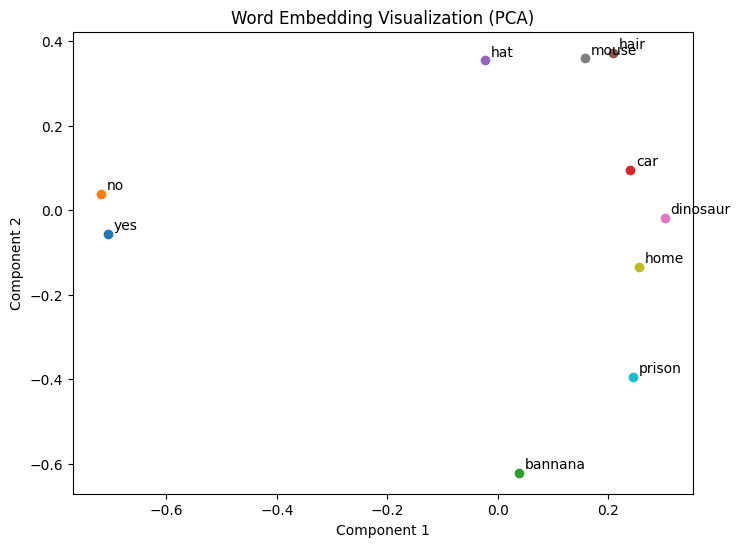

In [85]:
from sklearn.decomposition import PCA

# Get list of embeddings from batch
words = list(embeddings.keys())
vectors = np.array([embeddings[w] for w in words])

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("Word Embedding Visualization (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

Cosine similarity is very useful in embedding spaces because it can capture the smantic relationships that two words have. By focusing on vector directions (learning meaning dimensions), cosine similarity can check if two words go in the same direction/have similar meaning. This allows us to identifty words with similar meanings even with different contexts or frequencies. This is different to euclidean distance which would try and measure hwo close they are by distance rather than direction/angle.

## Designing a Novel Dissimilarity Metric

I will be using manhatten distance as my dissimilarity metric. Manhatten differences finds the sum of absolute differences in each direction/dimension. This ensures that large differences in any single embedding direction are fully accounted for which would highlight novelty/diversity better than cosine similarity.

In [88]:
from scipy.spatial.distance import cityblock
dist = cityblock(embedding1, embedding2)
print(f"\nManhatten Dissimilarity between '{word1}' and '{word2}': {dist:.4f}")


Manhatten Dissimilarity between 'yes' and 'no': 11.4075


In [91]:
def similarity_dissimilarity(embedding1, embedding2, similarity=True):
  if similarity:
    return cosine_similarity(embedding1, embedding2)
  else:
    return cityblock(embedding1, embedding2)

In [93]:
print(similarity_dissimilarity(get_embedding("bye", model), get_embedding("hi", model), True))
print(similarity_dissimilarity(get_embedding("bye", model), get_embedding("hi", model), False))

0.36858577
17.131298


In [95]:
pairs = []

n = int(input("How many word pairs do you want to compare? "))

for i in range(n):
    w1 = input(f"Pair {i+1} - Enter first word: ")
    w2 = input(f"Pair {i+1} - Enter second word: ")
    pairs.append((w1, w2))

How many word pairs do you want to compare? 5
Pair 1 - Enter first word: yes
Pair 1 - Enter second word: no
Pair 2 - Enter first word: hero
Pair 2 - Enter second word: villain
Pair 3 - Enter first word: rat
Pair 3 - Enter second word: car
Pair 4 - Enter first word: hatchet
Pair 4 - Enter second word: knife
Pair 5 - Enter first word: home
Pair 5 - Enter second word: dinosaur


In [101]:
embeddings = {}
results = []

useSim = input("Using similarity metric? (y/n) ").strip().lower() == 'y'

for w1, w2 in pairs:

    if w1 not in embeddings:
        embeddings[w1] = get_embedding(w1, model)

    if w2 not in embeddings:
        embeddings[w2] = get_embedding(w2, model)

    sim = similarity_dissimilarity(embeddings[w1], embeddings[w2], useSim)

    results.append((w1, w2, sim))

if useSim:
  print("\nSimilarity Results:")
else:
  print("\nDissimilarity Results:")
for w1, w2, sim in results:
    print(f"{w1} vs {w2}: {sim:.4f}")

Using similarity metric? (y/n) n

Dissimilarity Results:
yes vs no: 11.4075
hero vs villain: 15.8574
rat vs car: 16.8280
hatchet vs knife: 17.2420
home vs dinosaur: 17.8491


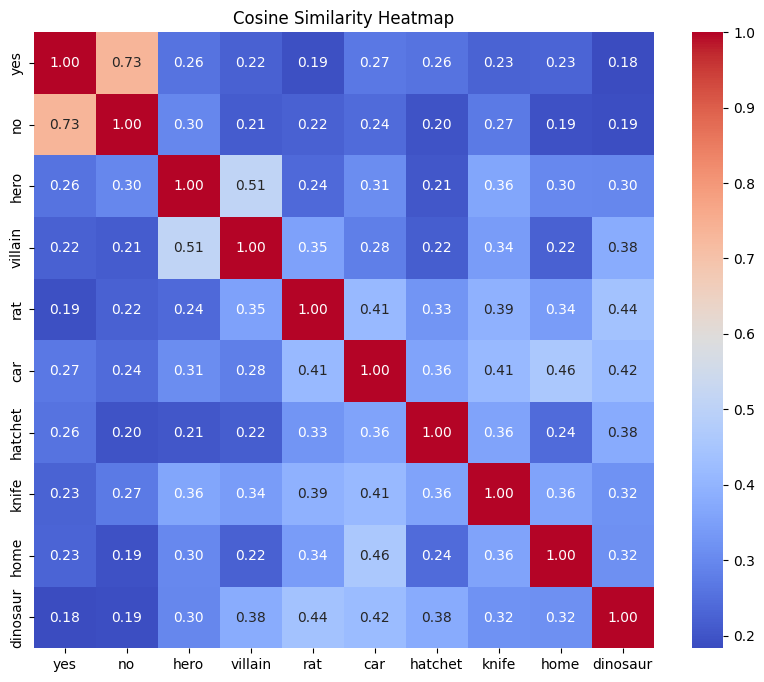

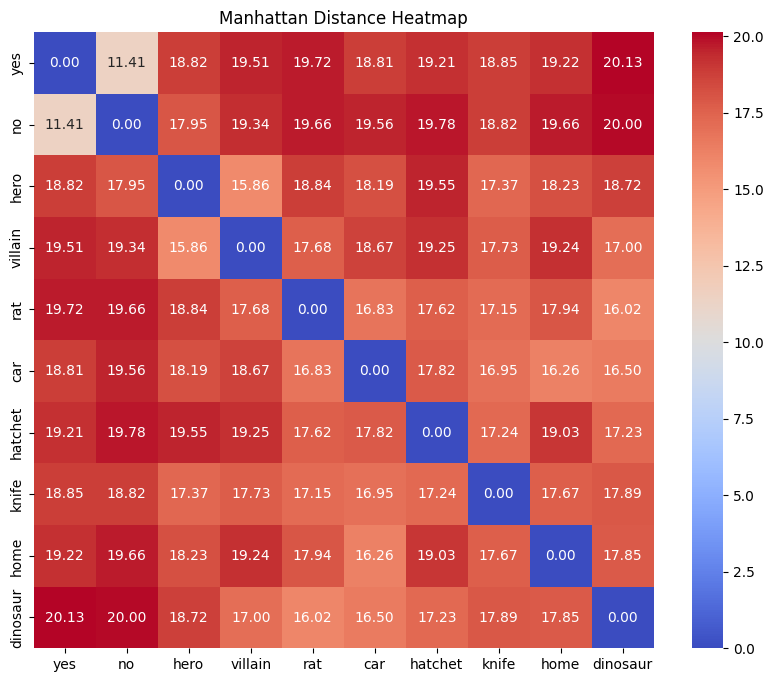

In [105]:
# Get all words
words = list(embeddings.keys())
num_words = len(words)

cosine_matrix = np.zeros((num_words, num_words))
manhattan_matrix = np.zeros((num_words, num_words))

# Compute all pairwise similarities/dissimilarities
for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):
        e1 = embeddings[w1]
        e2 = embeddings[w2]
        # Cosine similarity
        cosine_matrix[i, j] = similarity_dissimilarity(e1, e2, similarity=True)
        # Manhattan distance
        manhattan_matrix[i, j] = similarity_dissimilarity(e1, e2, similarity=False)

plt.figure(figsize=(10,8))
sns.heatmap(cosine_matrix, xticklabels=words, yticklabels=words, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cosine Similarity Heatmap")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(manhattan_matrix, xticklabels=words, yticklabels=words, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Manhattan Distance Heatmap")
plt.show()